导入依赖

In [1]:
import torch
import torchvision
from torch import nn, optim
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from torchvision import transforms, datasets
from models.GhostNet import GhostNet as ghost_original
from models.GhostNet_exp_GhostModule import GhostNet as ghost_exp_ghost
from models.GhostNet_paper import GhostNet as ghost_paper
from models.GhostNet_paper_expSe import GhostNet as ghost_se
from models.cnn_model2 import PrecisionBalancedCNN

设置随机种子

In [2]:
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # 如果使用多GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed = 100
# 在训练代码开头调用
set_seed(seed) # 42, 2025, 1024, 512, 100

导入数据集

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
def preprocessing(tensor):
    if tensor.mean() > 0.5:
        tensor = 1 - tensor
    return tensor

In [5]:
def tensor_transform(x):
    if x.shape[1] == 1:
        return x.repeat_interleave(3, dim= 1)
    elif x.shape[1] == 4:
        return x[:, :3, :, :]
    elif x.shape[1] == 3:
        return x
    else:
        raise ValueError('Invalid input shape')

tensor_rgb_transform = transforms.Lambda(tensor_transform)

In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Lambda(preprocessing),
    transforms.Normalize((0.1307, ), (0.3081, )),
    transforms.Grayscale(1)
])

In [7]:
test_db = datasets.ImageFolder(root= 'C:/Users/Administrator/Desktop/datas/test_data_black', transform= transform)
test_loader = DataLoader(test_db, batch_size= 10, shuffle= False)

In [8]:
mnist_db = datasets.MNIST(root='dataFolder/', transform= transform, train=True, download=True)
mnist_loader = DataLoader(mnist_db, batch_size=100, shuffle=True)

In [9]:
x, y = next(iter(test_loader))

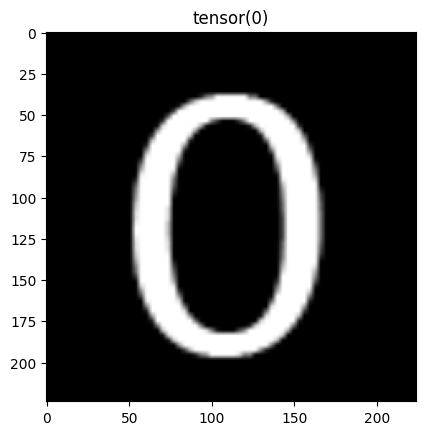

In [10]:
plt.figure()
plt.imshow(x[0][0].detach().numpy(), cmap='gray')
plt.title(y[0])
plt.show()

导入模型

In [11]:
ghost_1c_md = PrecisionBalancedCNN('ghost', 1)
ghost_1c_md.load_state_dict(torch.load(f'save_models/SimpleCNN/model_ghost_1C_MD_{seed}.pth'))
ghost_1c_md.to(device)
ghost_1c_md.eval()
print('ghost_1c_md loaded')

Using base_channels=48 for ghost
ghost_1c_md loaded


In [12]:
ghost_3c_md = PrecisionBalancedCNN('ghost', 3)
ghost_3c_md.load_state_dict(torch.load(f'save_models/SimpleCNN/model_ghost_3C_MD_{seed}.pth'))
ghost_3c_md.to(device)
ghost_3c_md.eval()
print('ghost_3c_md loaded')

Using base_channels=48 for ghost
ghost_3c_md loaded


In [13]:
# ghost_paper_1c_md = ghost_paper(in_ch=1)
# ghost_paper_1c_md.load_state_dict(torch.load(f'save_models/ghost/GhostNet_paper_1C_MD_{seed}.pth'))
# ghost_paper_1c_md.to(device)
# ghost_paper_1c_md.eval()
# print('GhostNet_paper_1C loaded!')

In [14]:
# ghost_paper_3c_md = ghost_paper(in_ch=3)
# ghost_paper_3c_md.load_state_dict(torch.load(f'save_models/ghost/GhostNet_paper_3C_MD_{seed}.pth'))
# ghost_paper_3c_md.to(device)
# ghost_paper_3c_md.eval()
# print('GhostNet_paper_3C loaded!')

In [15]:
# ghost_se_1c_md = ghost_se(in_ch=1)
# ghost_se_1c_md.load_state_dict(torch.load(f'save_models/ghost/GhostNet_se_1C_MD_{seed}.pth'))
# ghost_se_1c_md.to(device)
# ghost_se_1c_md.eval()
# print('GhostNet_se_1C loaded!')

In [16]:
# ghost_se_3c_md = ghost_se(in_ch=3)
# ghost_se_3c_md.load_state_dict(torch.load(f'save_models/ghost/GhostNet_se_3C_MD_{seed}.pth'))
# ghost_se_3c_md.to(device)
# ghost_se_3c_md.eval()
# print('GhostNet_se_3C loaded!')

In [17]:
# ghost_se2_1c_md = ghost_se2(in_ch=1)
# ghost_se2_1c_md.load_state_dict(torch.load(f'save_models/ghost/GhostNet_se2_1C_MD_{seed}.pth'))
# ghost_se2_1c_md.to(device)
# ghost_se2_1c_md.eval()
# print('GhostNet_se2_1C loaded!')

实验测试

In [18]:
# ghost_se2_3c_md = ghost_se2(in_ch=3)
# ghost_se2_3c_md.load_state_dict(torch.load(f'save_models/ghost/GhostNet_se2_3C_MD_{seed}.pth'))
# ghost_se2_3c_md.to(device)
# ghost_se2_3c_md.eval()
# print('GhostNet_se2_3C loaded!')

In [19]:
total = 0
idxs = []
correct_1c_md, correct_3c_md, correct_expgm_1c_md, correct_expgm_3c_md = 0, 0, 0, 0
correct_1c_mds, correct_3c_mds, correct_expgm_1c_mds, correct_expgm_3c_mds = [], [], [], []

with torch.no_grad():
    for idx, (x, y) in enumerate(test_loader):
        x, y = x.to(device), y.to(device)
        x_rgb = tensor_rgb_transform(x)
        out_1c_md = torch.argmax(ghost_1c_md(x), dim= -1)
        out_3c_md = torch.argmax(ghost_3c_md(x_rgb), dim= -1)
        # out_expgm_1c_md = torch.argmax(ghost_paper_1c_md(x), dim= -1)
        # out_expgm_3c_md = torch.argmax(ghost_paper_3c_md(x_rgb), dim= -1)

        total += x.size(0)
        correct_1c_md += (out_1c_md == y).sum().item()
        correct_3c_md += (out_3c_md == y).sum().item()

        # correct_expgm_1c_md += (out_expgm_1c_md == y).sum().item()
        # correct_expgm_3c_md += (out_expgm_3c_md == y).sum().item()

        if idx % 50 == 0:
            accu_1c_md = correct_1c_md / total
            accu_3c_md = correct_3c_md / total

            # accu_expgm_1c_md = correct_expgm_1c_md / total
            # accu_expgm_3c_md = correct_expgm_3c_md / total

            idxs.append(idx)
            
            correct_1c_mds.append(accu_1c_md)
            correct_3c_mds.append(accu_3c_md)

            # correct_expgm_1c_mds.append(accu_expgm_1c_md)
            # correct_expgm_3c_mds.append(accu_expgm_3c_md)

            print(f'Step: {idx}, \
                    1c_md accu: {accu_1c_md:.4f}, \
                    3c_md accu: {accu_3c_md:.4f}')
                    #paper_1c_md accu: {accu_expgm_1c_md:.4f}, \
                    #paper_3c_md accu: {accu_expgm_3c_md:.4f}
                    

Step: 0,                     1c_md accu: 0.8000,                     3c_md accu: 1.0000
Step: 50,                     1c_md accu: 0.7588,                     3c_md accu: 0.9510
Step: 100,                     1c_md accu: 0.8495,                     3c_md accu: 0.9396
Step: 150,                     1c_md accu: 0.8768,                     3c_md accu: 0.9477
Step: 200,                     1c_md accu: 0.8726,                     3c_md accu: 0.9269
Step: 250,                     1c_md accu: 0.8805,                     3c_md accu: 0.9247


数据可视化

In [20]:
# total = 0
# idxs = []
# correct_se_1c_md = 0
# correct_se_3c_md = 0
# correct_se2_1c_md = 0
# correct_se2_3c_md = 0
# correct_1c_md, correct_3c_md = 0, 0
# correct_1c_mds, correct_3c_mds = [], []
# correct_se_1c_mds = []
# correct_se_3c_mds = []
# correct_se2_1c_mds = []
# correct_se2_3c_mds = []

# with torch.no_grad():
#     for idx, (images, labels) in enumerate(test_loader):
#         images = images.to(device)
#         labels = labels.to(device)
#         img_rgb = tensor_rgb_transform(images)
#         out_se_1c_md = torch.argmax(ghost_se_1c_md(images), dim= -1)
#         out_se_3c_md = torch.argmax(ghost_se_3c_md(img_rgb), dim= -1)

#         out_se2_1c_md = torch.argmax(ghost_se2_1c_md(images), dim= -1)
#         out_se2_3c_md = torch.argmax(ghost_se2_3c_md(img_rgb), dim= -1)

#         out_1c_md = torch.argmax(ghost_1c_md(images), dim= -1)
#         out_3c_md = torch.argmax(ghost_3c_md(img_rgb), dim= -1)

#         total += labels.size(0)
#         correct_se_1c_md += (out_se_1c_md == labels).sum().item()
#         correct_se_3c_md += (out_se_3c_md == labels).sum().item()

#         correct_se2_1c_md += (out_se2_1c_md == labels).sum().item()
#         correct_se2_3c_md += (out_se2_3c_md == labels).sum().item()

#         correct_1c_md += (out_1c_md == labels).sum().item()
#         correct_3c_md += (out_3c_md == labels).sum().item()

#         if idx % 50 == 0:
#             accu_1c_md = correct_1c_md / total
#             accu_3c_md = correct_3c_md / total

#             accu_se_1c_md = correct_se_1c_md / total
#             accu_se_3c_md = correct_se_3c_md / total

#             accu_se2_1c_md = correct_se2_1c_md / total
#             accu_se2_3c_md = correct_se2_3c_md / total

#             idxs.append(idx)
#             correct_1c_mds.append(accu_1c_md)
#             correct_3c_mds.append(accu_3c_md)

#             correct_se_1c_mds.append(accu_se_1c_md)
#             correct_se_3c_mds.append(accu_se_3c_md)

#             correct_se2_1c_mds.append(accu_se2_1c_md)
#             correct_se2_3c_mds.append(accu_se2_3c_md)

#             print(f'idx: {idx}, accu_1c_md: {accu_1c_md:.4f}, accu_3c_md: {accu_3c_md:.4f}, accu_se_1c_md: {accu_se_1c_md:.4f}, accu_se_3c_md: {accu_se_3c_md:.4f}, accu_se2_1c_md: {accu_se2_1c_md:.4f}, accu_se2_3c_md: {accu_se2_3c_md:.4f}')

In [21]:
# with open('data_csv/GhostNet_se.csv', 'a+') as f:
#     for idx, m1, m2, m3, m4, m5, m6 in zip(idxs, correct_1c_mds, correct_3c_mds, correct_se_1c_mds, correct_se_3c_mds, correct_se2_1c_mds, correct_se2_3c_mds):
#         f.writelines(str(idx) + ',' + str(seed) + ',' + str(m1) + ',' + str(m2) + ',' + str(m3) + ',' + str(m4) + ',' + str(m5) + ',' + str(m6) + '\n')

In [22]:
# plt.figure(figsize= (10, 5))
# plt.plot(idxs, correct_1c_mds, label= f'GhostNet (MNIST 1C, seed={seed})')
# plt.plot(idxs, correct_3c_mds, label= f'GhostNet (MNIST 3C, seed={seed})')
# plt.plot(idxs, correct_expgm_1c_mds, label= f'GhostNet Exp GhostModule (MNIST 1C, seed={seed})')
# plt.plot(idxs, correct_expgm_3c_mds, label= f'GhostNet Exp GhostModule (MNIST 3C, seed={seed})')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.title('GhostNet and GhostNet Exp GhostModule Test on Test Data')
# plt.legend()
# plt.savefig(f'GhostNet_and_GhostNet_Exp_GhostModule_Test_on_Test_Data_{seed}.png')
# plt.show()

In [23]:
# with open('data_csv/GhostNet_paper.csv', 'a+') as f:
#     for idx, m1, m2, m3, m4 in zip(idxs, correct_1c_mds, correct_3c_mds, correct_expgm_1c_mds, correct_expgm_3c_mds):
#         f.writelines(str(idx) + ',' + str(seed) + ',' + str(m3) + ',' + str(m4) + ',' + str(m1) + ',' + str(m2) + '\n')
